# Koyna Dam 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd()
KOYNA_DIR = cwd


Import constants to help track units from the {ref}`units` module.

In [2]:
import veux
import xara

from xara.units import create_units

units = create_units(length="meter", mass="kg")
# units = create_units(system="iks")

GPa = units.GPa
MPa = units.MPa
m   = units.m
kg  = units.kg
kN  = units.kN


print(f"""
Units:
  {m   = }
  {kg  = }
  {kN  = }
  {GPa = }
""")



Units:
  m   = 1.0
  kg  = 1.0
  kN  = 1000.0
  GPa = 1000000000.0



## Modeling

### Parameters

In [3]:
mesh = dict(
    nx      =  8, # 20,
    ny_base =  8, #24,
    ny_top  = 10, #14
)

Ec = 31.027 * GPa
fc = 24.1 * MPa
ft = 2.9 * MPa
nu = 0.2
rho = 2643.0 * kg / (m ** 3)
zeta = 0.03
Gt = 0.073*(fc/MPa)**(0.018)*kN/m
Gc = (fc/ft)**2.0*Gt

from koyna import KoynaDam
koyna = KoynaDam(units=units, mesh=mesh)


### Define Material

In [4]:
material = xara.MultiaxialMaterial("FariaPlasticDamage",
                                 E=Ec,
                                 nu=nu,
                                 Fc=fc,
                                 Ft=ft,
                                 beta=0.5,
                                 An=2,
                                 Bn=0.75,
                                 Ap=0.5,
                                 density=rho
                                )


# material = xara.MultiaxialMaterial("LeeFenves",
#                                  E=Ec,
#                                  nu=nu,
#                                  Fc=fc,
#                                  Ft=ft,
#                                  Gc=Gc, #5.69*kN/m,
#                                  Gt=Gt, #0.04*kN/m,
#                                  Lc=koyna.L_base/mesh["nx"],
#                                  Lt=koyna.L_base/mesh["nx"],
#                                 #  Ftype="DP",
#                                 #  Dt=0.51,
#                                  aC=4.0,
#                                 #  Dc=0.45,
#                                 #  alphap=0.2,
#                                  density=rho
#                                 )

print(material.asdict())


{'name': 1, 'type': 'FariaPlasticDamage', 'E': 31027000000.0, 'nu': 0.2, 'Ft': 2900000.0, 'Fc': 24100000.0, 'beta': 0.5, 'Ap': 0.5, 'An': 2, 'Bn': 0.75, 'density': 2643}


### Mesh Generation

The element mesh is generated using the {py:meth}`Model.surface` method.

In [5]:

model = koyna.create_model(material, element="Q8")

crest = koyna.crest_node(model)

print(f'Nodes: {len(model.getNodeTags())}')
print(f'Elements: {len(model.getEleTags())}')
print(f'Crest node: {crest}')


artist = veux.create_artist(model, ndf=2)
artist.draw_nodes(size=4)
artist.draw_outlines()
artist

Nodes: 485
Elements: 144
Crest node: 469


In [6]:

eigenvalues = model.eigen(5)
periods = [2.0 * np.pi / np.sqrt(value) for value in eigenvalues]

omega_1 = np.sqrt(eigenvalues[0])
beta_k  = 2.0 * zeta / omega_1

print('Eigen analysis completed.')
print('First five periods (s):')
for i, period in enumerate(periods, start=1):
    print(f'  Mode {i}: {period:.6e}')

Eigen analysis completed.
First five periods (s):
  Mode 1: 3.322183e-01
  Mode 2: 1.250745e-01
  Mode 3: 9.214003e-02
  Mode 4: 6.347170e-02
  Mode 5: 4.154153e-02


## Gravity


In [7]:
koyna.static_analysis(model)

Upstream water-loaded nodes: 30


In [8]:
from xara.post import NodalStress

artist = veux.create_artist(model, ndf=2)

artist.draw_outlines()
artist.draw_outlines(state=model.nodeDisp, scale=1e3*units.m)

artist.draw_surfaces(state=model.nodeDisp, scale=1e3*units.m, field=NodalStress(model, "sxx"))
artist


## Eigenvalues, and Damping

In [9]:
koyna.apply_damping(model, zeta=zeta)

Gravity analysis completed.
First five periods (s):
  Mode 1: 3.783810e-01
  Mode 2: 1.499350e-01
  Mode 3: 9.371826e-02
  Mode 4: 7.836118e-02
  Mode 5: 5.273726e-02
Stiffness-proportional damping beta_k = 3.613272e-03


Structural modes are similarly rendered using the {ref}`nodeEigenvector` method.

In [10]:
mode = 2
artist = veux.create_artist(model, ndf=2)

artist.draw_outlines()
artist.draw_outlines(state=lambda n: model.nodeEigenvector(n, mode), scale=10000)
artist

## Transient Analysis


Input duration: 10.000 s
Data time step: 0.010 s


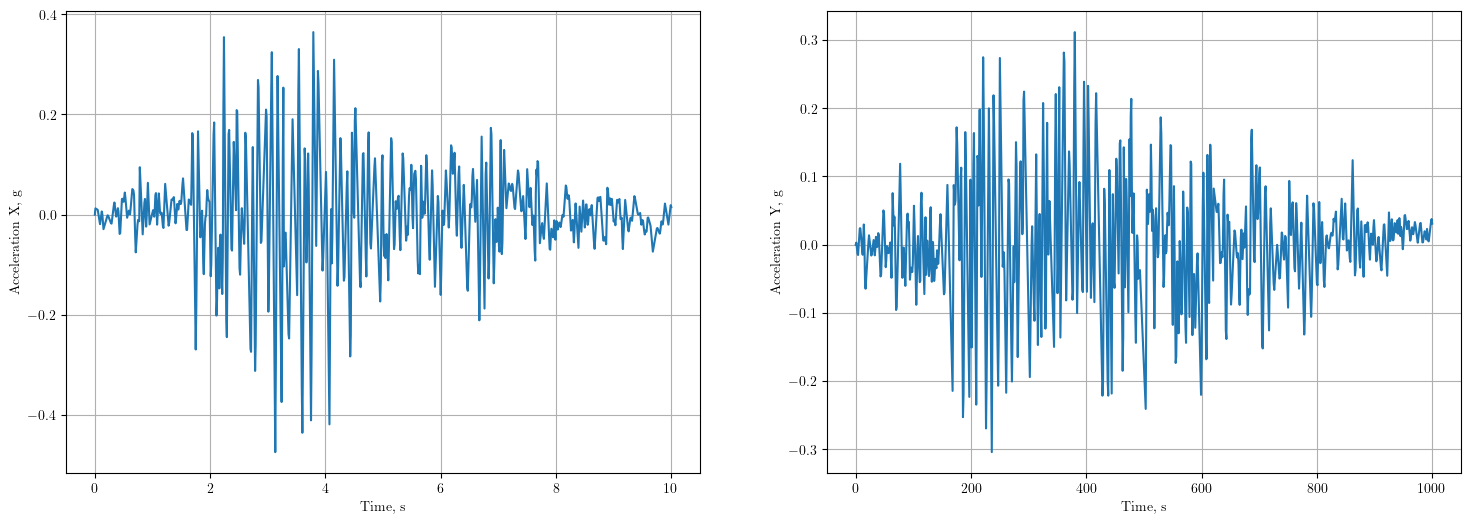

In [11]:
accel_x = np.loadtxt(KOYNA_DIR / 'data' / 'koyna_x_series.txt')
accel_y = np.loadtxt(KOYNA_DIR / 'data' / 'koyna_y_series.txt')

dt_data = 0.01
n_steps = len(accel_x)-1
duration = n_steps * dt_data
time = np.linspace(0,duration,len(accel_x))

print(f'Input duration: {duration:.3f} s')
print(f'Data time step: {dt_data:.3f} s')

fig, ax = plt.subplots(1,2,figsize=(18, 6))
ax[0].plot(time,accel_x)
ax[0].set_xlabel('Time, s')
ax[0].set_ylabel('Acceleration X, g')
ax[0].grid()
ax[1].plot(accel_y);
ax[1].set_xlabel('Time, s')
ax[1].set_ylabel('Acceleration Y, g')
ax[1].grid()

In [12]:

model.timeSeries('Path', 11, dt=dt_data, values=accel_x, factor=units.gravity)
model.timeSeries('Path', 12, dt=dt_data, values=accel_y, factor=units.gravity)

model.pattern("UniformExcitation", 11, 1, accel=11)
model.pattern("UniformExcitation", 12, 2, accel=12)


The following cell uses the [tqdm](https://tqdm.github.io/) package to print a progress bar. 
If the import fails, the package can be installed by running:

```shell
python -m pip install tqdm
```

In [13]:
from tqdm import tqdm


model.wipeAnalysis()
model.constraints('Plain')
model.numberer('Plain')
model.system('Umfpack02')
model.test('EnergyIncr', 1.0e-12, 20, 0)
# model.algorithm("Broyden")
model.algorithm("KrylovNewton")
# model.algorithm("NewtonLineSearch", 0.6, type="RegulaFalsi")
model.integrator("Newmark", 0.5, 0.25)
model.analysis("Transient")

dt = 0.0015 #0.005 #

crest_disp=[model.nodeDisp(crest,1)]

steps = int(duration/dt)
for i in tqdm(range(steps)):

    status = model.analyze(1, dt)
    if status != xara.successful:
        break
        raise RuntimeError(f"analysis failed at time {model.getTime()}")

    crest_disp.append(model.nodeDisp(crest,1))



100%|██████████| 6666/6666 [01:18<00:00, 85.34it/s]


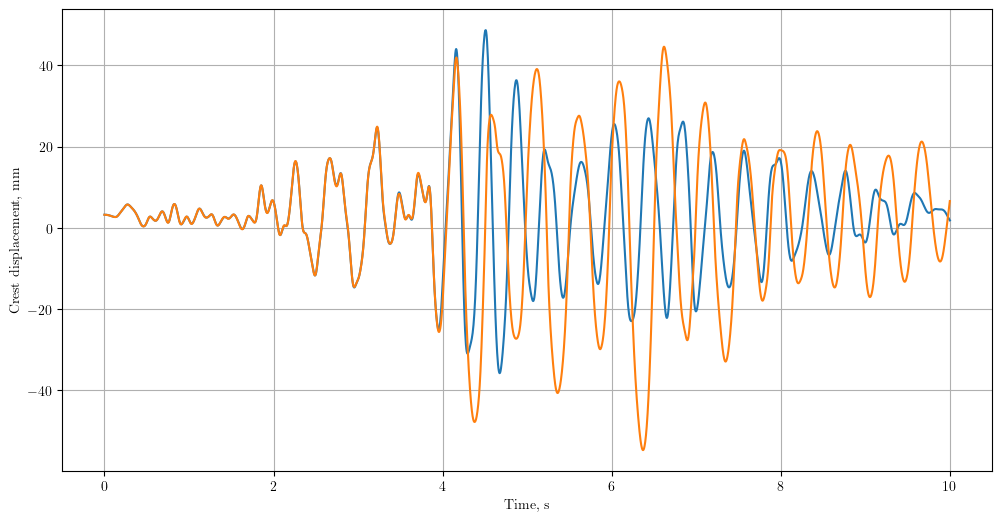

In [14]:
mm = units.millimeter

fig, ax = plt.subplots(figsize=(12, 6))
tref, uref = np.loadtxt("out/crest.txt",unpack=True)
ax.plot(tref, uref/mm,label='Reference')


u_crest = np.clip(np.array(crest_disp)/mm, -75, 75)
ax.plot(np.linspace(0,model.getTime(),len(crest_disp)), u_crest, label='Simulation')
ax.set_xlabel('Time, s')
ax.set_ylabel('Crest displacement, mm')
ax.grid(True)

In [15]:
M = model.getTangent(m=1, c=0, k=0)
np.sum(M)

np.float64(23092874.75393267)

In [16]:

artist = veux.create_artist(model, ndf=2)

artist.draw_outlines()
artist.draw_outlines(state=model.nodeDisp, scale=1000)
artist.draw_surfaces(state=model.nodeDisp, scale=1000, field=NodalStress(model, "sxx"))
artist